In [229]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pca import pca
from sklearn import datasets
from sklearn.decomposition import PCA

In [230]:
# from GitHub
username = "datagus"
repository = "ASDA2025"
directory = "datasets/homework_week10/happy.csv"

github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"

# read CSV (note: separator is ;)
happy_df = pd.read_csv(github_url)

# convert quality to string
#wine_df["quality"] = wine_df["quality"].astype(str)

#wine_df=wine_df.loc[wine_df['quality'].isin(['5','6','7'])]

happy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [231]:
#from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/income.xlsx"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
income_xls = pd.ExcelFile(github_url)
income_df = pd.read_excel(income_xls, 'List of economies')

In [232]:
happy_df['Country or region'] = happy_df['Country or region'].str.strip()
income_df['Economy'] = income_df['Economy'].str.strip()


In [233]:
happy_df = happy_df.merge(
    income_df,
    left_on='Country or region',
    right_on='Economy',
    how='left'
)


In [234]:
features = ['GDP per capita', 'Social support', 'Healthy life expectancy',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

X = happy_df[features]


[18-12-2025 23:34:58] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 6 columns of the input data.
[18-12-2025 23:34:58] [pca.pca] [INFO] Fit using PCA.
[18-12-2025 23:34:58] [pca.pca] [INFO] Compute loadings and PCs.
[18-12-2025 23:34:58] [pca.pca] [INFO] Compute explained variance.
[18-12-2025 23:34:58] [pca.pca] [INFO] The top 5 principal component(s) explains >= 95.00% of the explained variance.
[18-12-2025 23:34:58] [pca.pca] [INFO] The PCA reduction is performed on 6 variables (columns) of the input dataframe.
[18-12-2025 23:34:58] [pca.pca] [INFO] Fit using PCA.
[18-12-2025 23:34:58] [pca.pca] [INFO] Compute loadings and PCs.
[18-12-2025 23:34:58] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[5]
[18-12-2025 23:34:58] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[18-12-2025 23:34:58] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[18

(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': 'The top 5 Principal Component(s) explains [97.43%] of the variance.'}, xlabel='PC1 (48.8% expl.var)', ylabel='PC2 (23.2% expl.var)'>)

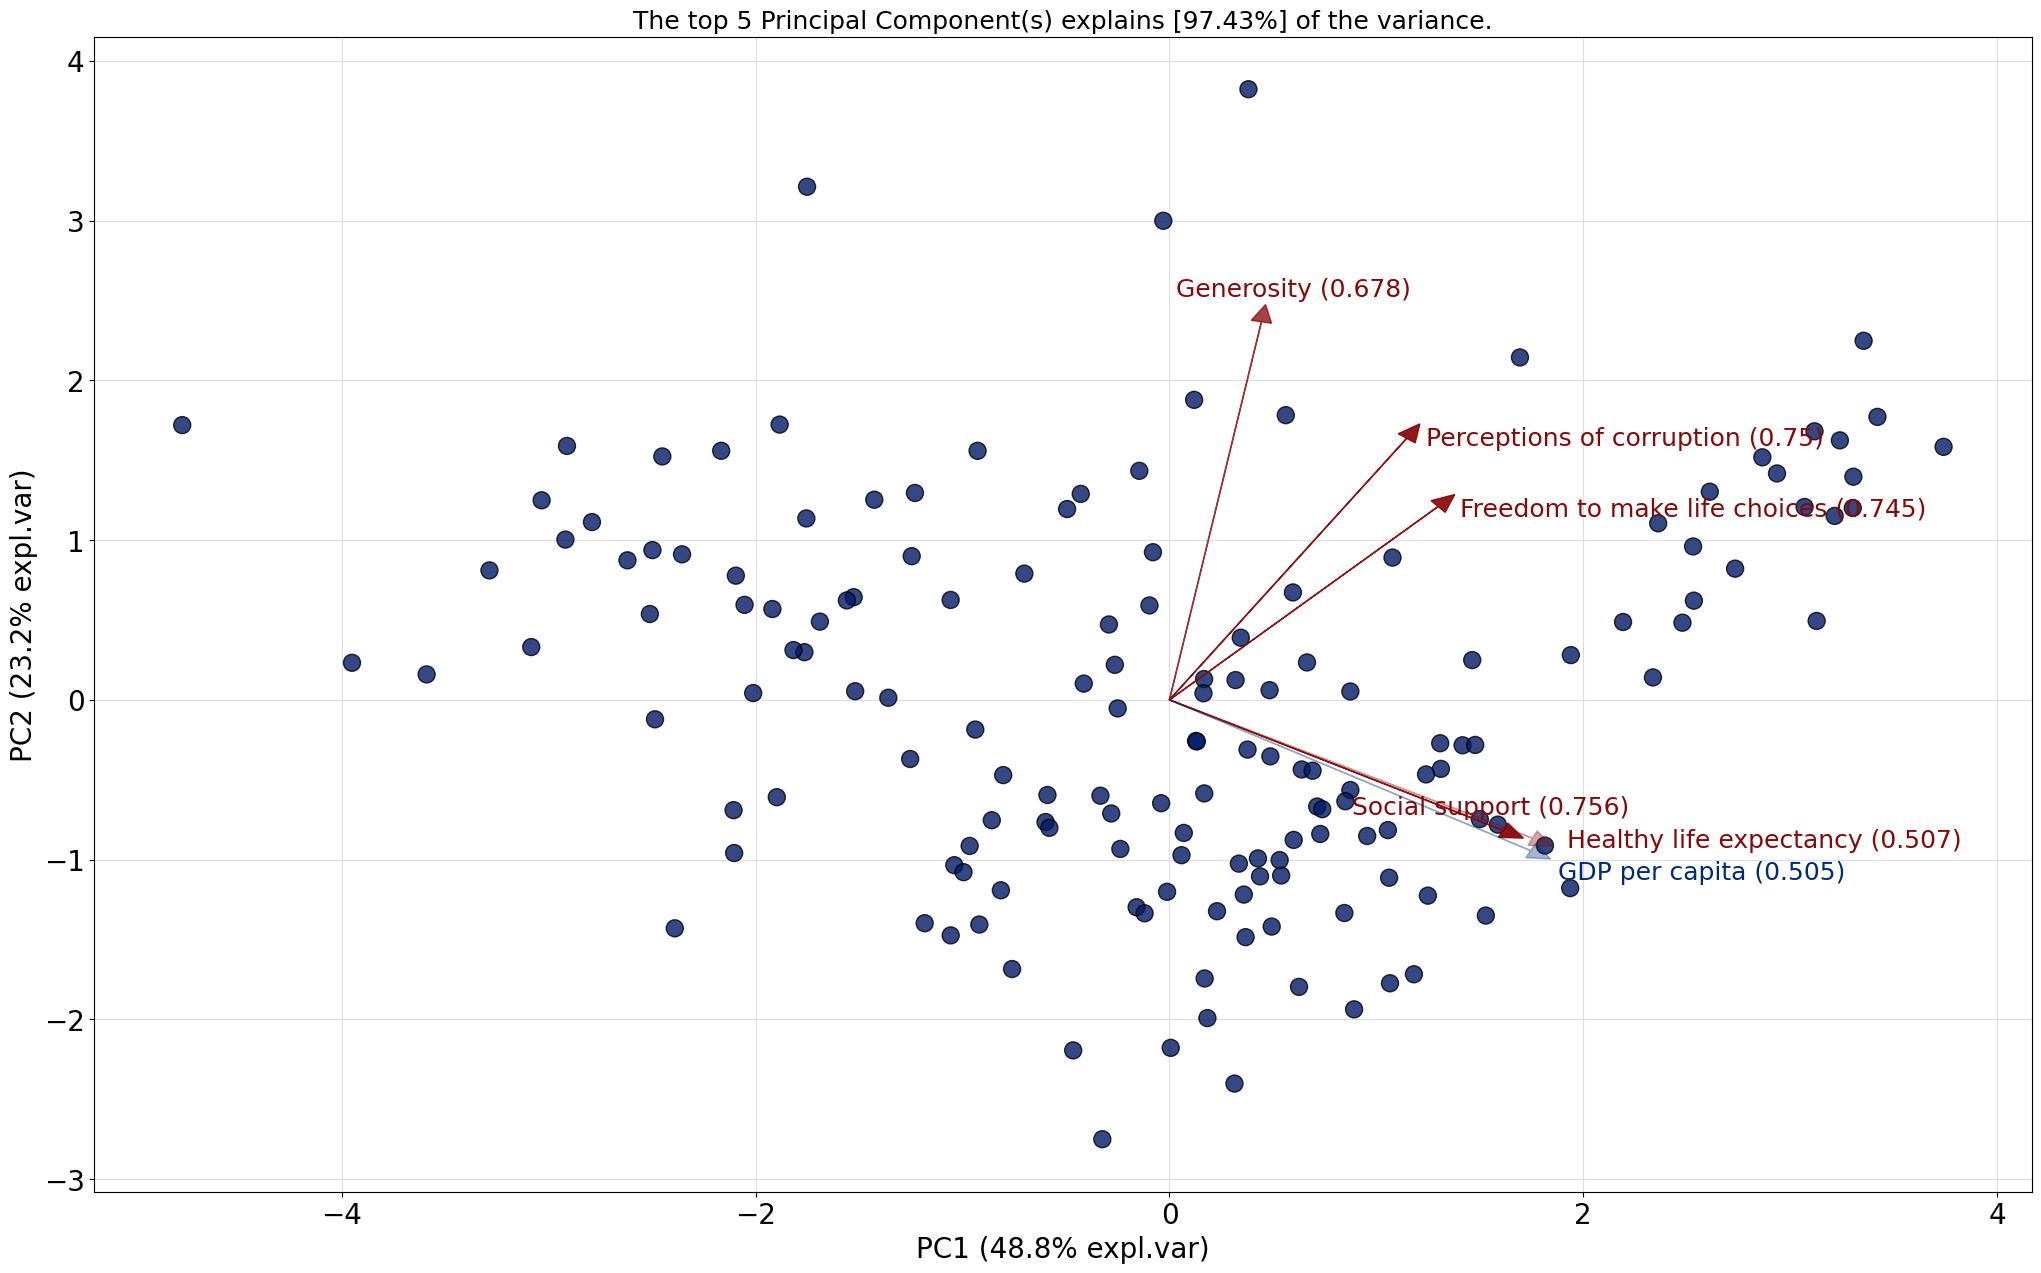

In [235]:
df = happy_df.copy()
y = df['Country or region'] 
X = happy_df[features]

# Scale the data
X_scaled = StandardScaler().fit_transform(X)
labels = X.columns


# PCA
model = pca()
#results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

# Scatter plot with loadings
model.biplot()


[18-12-2025 23:34:59] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 6 columns of the input data.
[18-12-2025 23:34:59] [pca.pca] [INFO] Fit using PCA.
[18-12-2025 23:34:59] [pca.pca] [INFO] Compute loadings and PCs.
[18-12-2025 23:34:59] [pca.pca] [INFO] Compute explained variance.
[18-12-2025 23:34:59] [pca.pca] [INFO] The top 5 principal component(s) explains >= 95.00% of the explained variance.
[18-12-2025 23:34:59] [pca.pca] [INFO] The PCA reduction is performed on 6 variables (columns) of the input dataframe.
[18-12-2025 23:34:59] [pca.pca] [INFO] Fit using PCA.
[18-12-2025 23:34:59] [pca.pca] [INFO] Compute loadings and PCs.
[18-12-2025 23:34:59] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[5]
[18-12-2025 23:34:59] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[18-12-2025 23:34:59] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[18

(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': 'The top 5 Principal Component(s) explains [97.43%] of the variance.'}, xlabel='PC1 (48.8% expl.var)', ylabel='PC2 (23.2% expl.var)'>)

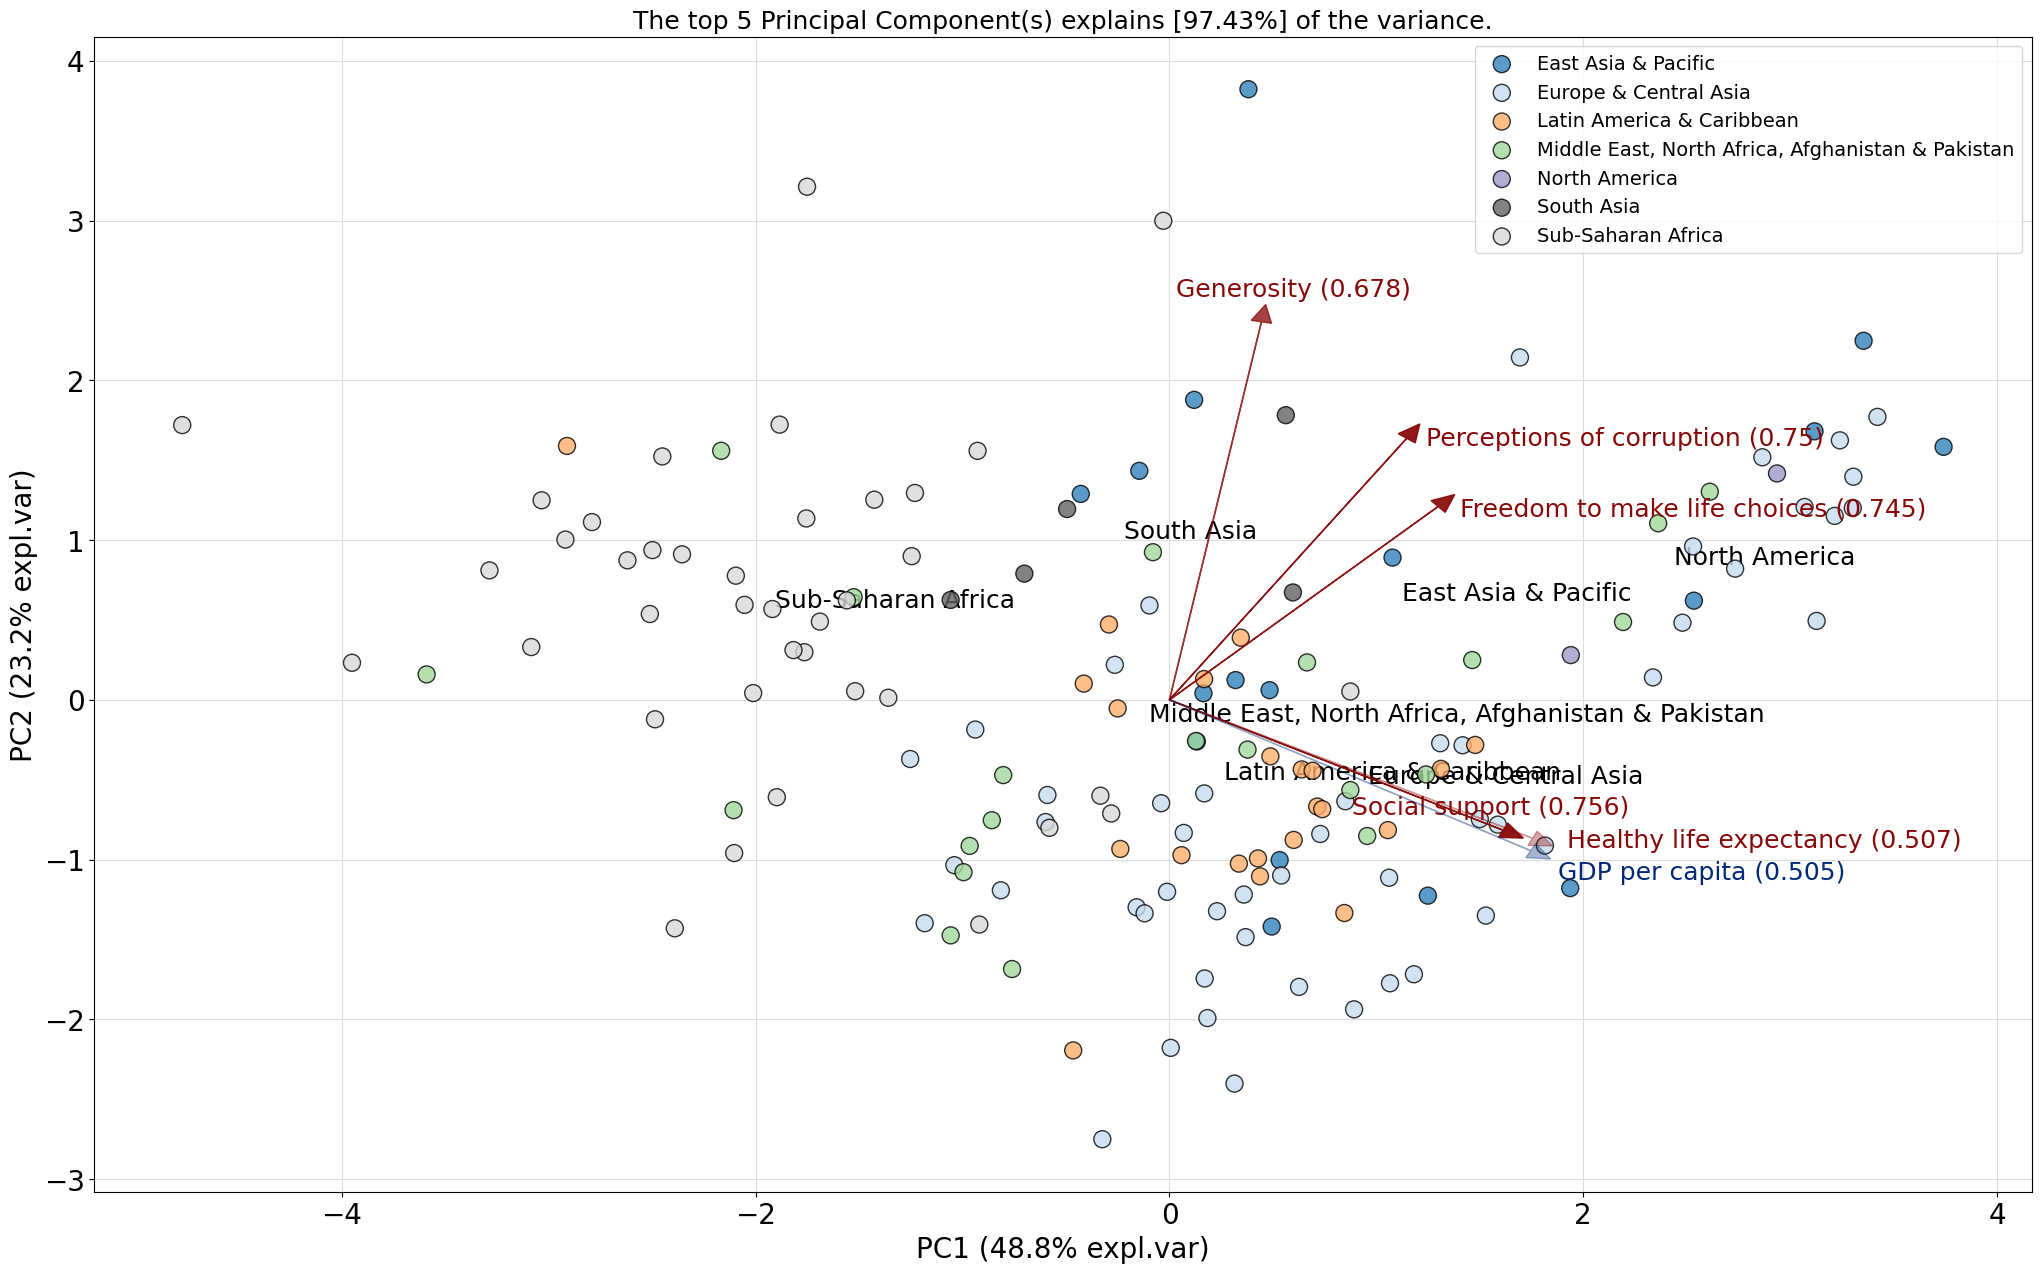

In [236]:
df = happy_df.copy()
y = df['Region'] 
X = happy_df[features]

# Scale the data
X_scaled = StandardScaler().fit_transform(X)
labels = X.columns


# PCA
model = pca()
#results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

# Scatter plot with loadings
model.biplot()



## Loadings

In [238]:
model.results['topfeat']

,PC,feature,loading,type
0,PC1,Healthy life expectancy,0.507478,best
1,PC2,Generosity,0.677582,best
2,PC3,Freedom to make life choices,0.744680,best
3,PC4,Perceptions of corruption,0.749989,best
4,PC5,Social support,0.756395,best
5,PC1,GDP per capita,0.504522,weak


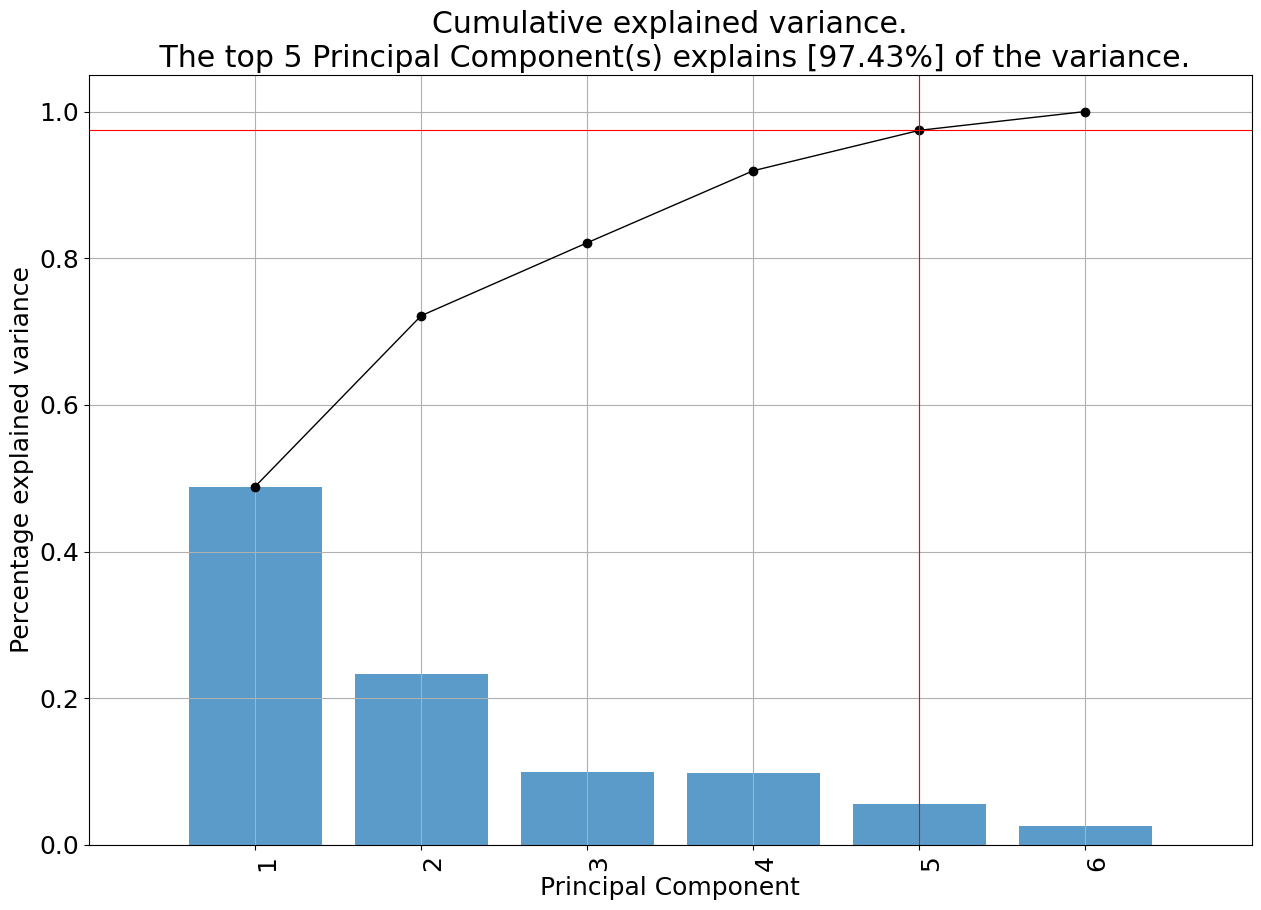

In [239]:
model.plot();